In [1]:
%run import_libs.py

In [2]:
allImages = glob.glob('../images/*/*')
crop_frac = 0.20

In [3]:
for i in allImages:
    stim_image = cv2.imread(i)
    stim_image = cv2.resize(stim_image, (540, 540))
    imheight_quarter = int(stim_image.shape[0]/4)
    probeheight_half = int(stim_image.shape[0] * np.sqrt(crop_frac) / 2)

     # if folder for this probe doesn't exist, make folder 
    paths = i.split('\\')
    if not os.path.exists('../probes_20perc' + '/'+ paths[1]):
        os.makedirs('../probes_20perc' + '/'+ paths[1])

    #make 6 probe images, later we will visually inspect them and choose the best one for each image
    for reps in range(6):
        while True:
            dx, dy = np.random.uniform(-imheight_quarter, imheight_quarter, 2)
            if dx**2 + dy**2 <= imheight_quarter**2:
                break
        imCtr = np.array([int(imheight_quarter *2 ) + int(dy), int(imheight_quarter *2 ) + int(dx)])

        # cut out a square region of the image centered at imCtr with side length imheight_quarter*2//2.25
        probe_image = stim_image[imCtr[0]-probeheight_half:imCtr[0]+probeheight_half, imCtr[1]-probeheight_half:imCtr[1]+probeheight_half, :]

        #save the probe image to the probes folder with a unique name
        probe_path = paths[1] +'/'+ paths[2].split('.')[0] + '_' + str(reps) +'.'+i.split('.')[-1]
        if not os.path.exists(f"../probes_20perc/{probe_path}"):
            cv2.imwrite(f"../probes_20perc/{probe_path}",cv2.resize(probe_image, (270,270)) )

# examples

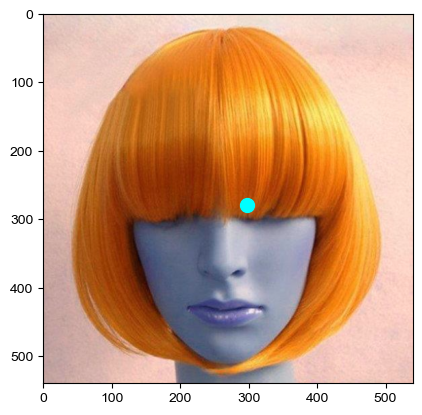

In [6]:
plt.imshow(stim_image)
plt.plot(imCtr[1], imCtr[0], marker='o', color='cyan', markersize=10)

In [7]:
print(f"Probe height: {probe_image.shape[0]}, \n \
      probe height proportion of image height: {probe_image.shape[0]*100/stim_image.shape[0]:.2f}, \n \
      proportion of probe size: {(probe_image.shape[0]/stim_image.shape[0])**2*100:.2f}%")

Probe height: 240, 
       probe height proportion of image height: 44.44, 
       proportion of probe size: 19.75%


# load probe

In [ ]:
root = 'C:/Users/yud070.AD/Desktop/gazeObject_TPGtach-expEL/'
%run {root + 'gen_exp_stim_path.py'}

In [397]:
#readin the trial set df
stimDf = pd.read_csv(root + 'experiment_file.csv')

In [398]:
random_row = np.random.randint(320)
stim_path, probe_path = \
             stimDf.iloc[random_row,:][['stimPath','probePath']].values

image = cv2.imread(stim_path)
probe = cv2.imread(probe_path)

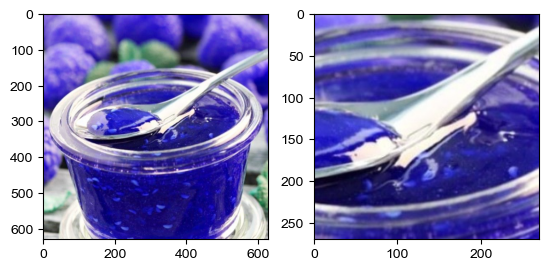

In [399]:
fig,ax = plt.subplots(ncols =2)


ax[0].imshow(image)
ax[1].imshow(probe)